# Subspace analysis

In [6]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

import pyaldata as pyal
import numpy as np
import matplotlib.pyplot as plt
import scipy

from sklearn.linear_model import LinearRegression

import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt


In [2]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_06_14_00',
    combine_time_bins=False
)
df_ = handler.df

ValueError: No objects to concatenate

In [ ]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -10, rel_end= 100)

In [67]:
from_area = 'MOp_rates'
to_area = 'CP_rates'

# Get regressor
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), from_area, to_area)

# Get subspace projector
comm_subspace_mop_cp = subspaces.get_output_potent_projector(comm_lr)

# Variances
comm_variances_mop_cp = subspaces.variance_in_subspace_df(perturb_td, from_area, comm_subspace_mop_cp)

In [66]:
from_area = 'CP_rates'
to_area = 'MOp_rates'

# Get regressor
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), from_area, to_area)

# Get subspace projector
comm_subspace_cp_mop = subspaces.get_output_potent_projector(comm_lr)

# Variances
comm_variances_cp_mop= subspaces.variance_in_subspace_df(perturb_td, from_area, comm_subspace_cp_mop)

In [69]:
projected_mop_cp = np.array([arr @ comm_subspace_mop_cp for arr in perturb_td.MOp_rates.values])
projected_cp_mop = np.array([arr @ comm_subspace_cp_mop for arr in perturb_td.CP_rates.values])

In [75]:
targets = df.values_Sol_direction.values.tolist()

In [77]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB


score_mop_cp = cross_val_score(
    GaussianNB(), projected_mop_cp.reshape(-1, projected_mop_cp.shape[1]*projected_mop_cp.shape[2]), 
    targets, scoring="accuracy", cv=5).mean()

score_cp_mop = cross_val_score(
    GaussianNB(), projected_cp_mop.reshape(-1, projected_cp_mop.shape[1]*projected_cp_mop.shape[2]), 
    targets, scoring="accuracy", cv=5).mean()

print(score_mop_cp, score_cp_mop)

0.3363636363636363 0.22211668928086842


In [105]:
output_null_subspace.shape

(178, 0)

In [113]:
areas = ['MOp', 'CP', 'SSp', 'VAL']
data = []
for from_area in areas[:1]:
    data_ = []
    for to_area in areas[1:]:
        print(from_area, to_area)
        comm_lr = pyal.fit_regressor_model(df, LinearRegression(), f'{from_area}_rates', f'{to_area}_rates')
        comm_subspace = subspaces.get_output_potent_projector(comm_lr)
        output_null_subspace = subspaces.get_output_null_projector(comm_lr)

        projected_arr = np.array([arr @ output_null_subspace for arr in perturb_td[f'{from_area}_rates'].values])
        cv_score = cross_val_score(
                GaussianNB(), projected_arr.reshape(-1, projected_arr.shape[1]*projected_arr.shape[2]), 
                targets, scoring="accuracy", cv=5
            ).mean()
        data_.append(cv_score)
        print(f'Comm. subspace {from_area} -> {to_area} score: {cv_score}')
    data_ = np.array(data_)
    data.append(data_)
data = np.array(data)

MOp CP
Comm. subspace MOp -> CP score: 0.17706919945725916
MOp SSp
Comm. subspace MOp -> SSp score: 0.2853459972862958
MOp VAL
Comm. subspace MOp -> VAL score: 0.26146540027137044


<Axes: >

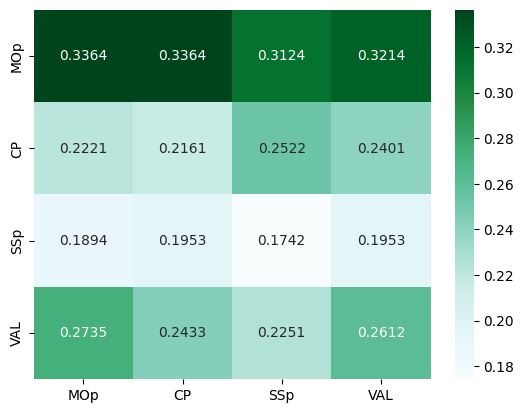

In [93]:
import seaborn as sns
sns.heatmap(
    data,
    xticklabels=areas,
    yticklabels=areas,
    # center=0,
    # vmin=0,
    # vmax=1,
    cmap= 'BuGn',#'BrBG',
    annot=True,
    fmt=".4f",
    # cbar_kws={"label": "Δ Lag (ms)"}
)

In [98]:
df.columns

Index(['animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       'values_before_camera_trigger', 'idx_before_camera_trigger',
       'idx_motion', 'values_Sol_direction', 'idx_Sol_direction',
       'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on',
       'idx_earthquake_duration', 'idx_session_timer', 'values_MotSen1_X',
       'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center',
       'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip', 'all_chan_best', 'all_unit_guide',
       'al

In [ ]:
from tools.dimensionality.cca import _roll_array


areas = ['MOp', 'CP', 'SSp', 'VAL']
data_delayed = []

shift_dict = {
    'MOp':{
        'MOp': 0,
        'SSp': 0,
        'CP': -1,
        'VAL': -3
    },
    'SSp':{
        'MOp': 1,
        'SSp': 0,
        'CP': 0,
        'VAL': -2
    },
    'CP':{
        'MOp': 2,
        'SSp': 1,
        'CP': 0,
        'VAL': -2
    },
    'VAL':{
        'MOp': 4,
        'SSp': 2,
        'CP': 0,
        'VAL': 0
    },

}

for from_area in areas:
    data_ = []
    for to_area in areas:
        comm_lr = LinearRegression()
        X = pyal.concat_trials(df, f'{from_area}_rates')
        Y = pyal.concat_trials(df, f'{to_area}_rates')
        Y_delayed = _roll_array(Y, shift=shift_dict[from_area][to_area])
        print(shift_dict[from_area][to_area])

        comm_lr.fit(X, Y_delayed)
        comm_subspace = subspaces.get_output_potent_projector(comm_lr)
        projected_arr = np.array([arr @ comm_subspace for arr in perturb_td[f'{from_area}_rates'].values])
        cv_score = cross_val_score(
                GaussianNB(), projected_arr.reshape(-1, projected_arr.shape[1]*projected_arr.shape[2]), 
                targets, scoring="accuracy", cv=5
            ).mean()
        data_.append(cv_score)
        # print(f'Comm. subspace {from_area} -> {to_area} score: {cv_score}')
    data_ = np.array(data_)
    data_delayed.append(data_)
data_delayed = np.array(data_delayed)

<Axes: >

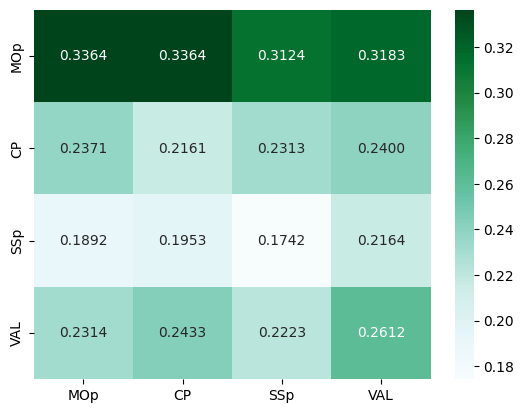

In [97]:
import seaborn as sns
sns.heatmap(
    data_delayed,
    xticklabels=areas,
    yticklabels=areas,
    # center=0,
    # vmin=0,
    # vmax=1,
    cmap= 'BuGn',#'BrBG',
    annot=True,
    fmt=".4f",
    # cbar_kws={"label": "Δ Lag (ms)"}
)

In [117]:
keypoint = 'left_ankle'
for from_area in areas:
    comm_lr = pyal.fit_regressor_model(df, LinearRegression(), f'{from_area}_rates', keypoint)
    comm_subspace = subspaces.get_output_potent_projector(comm_lr)
    output_null_subspace = subspaces.get_output_null_projector(comm_lr)
    projected_arr = np.array([arr @ output_null_subspace for arr in perturb_td[f'{from_area}_rates'].values])
    cv_score = cross_val_score(
            GaussianNB(), projected_arr.reshape(-1, projected_arr.shape[1]*projected_arr.shape[2]), 
            targets, scoring="accuracy", cv=5
        ).mean()
    print(f'Comm. subspace {from_area} -> {keypoint} score: {cv_score}')
    

Comm. subspace MOp -> left_ankle score: 0.24604251469923116
Comm. subspace CP -> left_ankle score: 0.20719131614654004
Comm. subspace SSp -> left_ankle score: 0.20438715513342376
Comm. subspace VAL -> left_ankle score: 0.20741745816372684


In [116]:
keypoint = 'right_ankle'
for from_area in areas:
    comm_lr = pyal.fit_regressor_model(df, LinearRegression(), f'{from_area}_rates', keypoint)
    comm_subspace = subspaces.get_output_potent_projector(comm_lr)
    output_null_subspace = subspaces.get_output_null_projector(comm_lr)
    projected_arr = np.array([arr @ comm_subspace for arr in perturb_td[f'{from_area}_rates'].values])
    cv_score = cross_val_score(
            GaussianNB(), projected_arr.reshape(-1, projected_arr.shape[1]*projected_arr.shape[2]), 
            targets, scoring="accuracy", cv=5
        ).mean()
    print(f'Comm. subspace {from_area} -> {keypoint} score: {cv_score}')
    

Comm. subspace MOp -> right_ankle score: 0.1350067842605156
Comm. subspace CP -> right_ankle score: 0.1290818634102216
Comm. subspace SSp -> right_ankle score: 0.11705110809588422
Comm. subspace VAL -> right_ankle score: 0.13211216644052465


In [141]:
import tools.dataTools as dt
all_kinematics = ['left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip']

df = dt.add_bhv(df, all_kinematics)
scores_comm_subspace = []
for from_area in areas:
    comm_lr = pyal.fit_regressor_model(df, LinearRegression(), f'{from_area}_rates', 'bhv')
    comm_subspace = subspaces.get_output_potent_projector(comm_lr)
    output_null_subspace = subspaces.get_output_null_projector(comm_lr)
    projected_arr = np.array([arr @ comm_subspace for arr in perturb_td[f'{from_area}_rates'].values])
    cv_score = cross_val_score(
            GaussianNB(), projected_arr.reshape(-1, projected_arr.shape[1]*projected_arr.shape[2]), 
            targets, scoring="accuracy", cv=5
        )
    scores_comm_subspace.append(cv_score)
    print(f'Comm. subspace {from_area} -> {keypoint} score: {cv_score.mean()}')
scores_comm_subspace = np.array(scores_comm_subspace)

Comm. subspace MOp -> left_ankle score: 0.32392582541836273
Comm. subspace CP -> left_ankle score: 0.2521935775667119
Comm. subspace SSp -> left_ankle score: 0.17431026684758028
Comm. subspace VAL -> left_ankle score: 0.18331071913161465


In [142]:
import tools.dataTools as dt
all_kinematics = ['left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip']


df = dt.add_bhv(df, all_kinematics)
scores_null_space = []
for from_area in areas:
    comm_lr = pyal.fit_regressor_model(df, LinearRegression(), f'{from_area}_rates', 'bhv')
    comm_subspace = subspaces.get_output_potent_projector(comm_lr)
    output_null_subspace = subspaces.get_output_null_projector(comm_lr)
    projected_arr = np.array([arr @ output_null_subspace for arr in perturb_td[f'{from_area}_rates'].values])
    cv_score = cross_val_score(
            GaussianNB(), projected_arr.reshape(-1, projected_arr.shape[1]*projected_arr.shape[2]), 
            targets, scoring="accuracy", cv=5
        )
    scores_null_space.append(cv_score)
    print(f'Comm. subspace {from_area} -> {keypoint} score: {cv_score.mean()}')
scores_null_space = np.array(scores_null_space)

Comm. subspace MOp -> left_ankle score: 0.2975576662143826
Comm. subspace CP -> left_ankle score: 0.2010854816824966
Comm. subspace SSp -> left_ankle score: 0.15015829941203077
Comm. subspace VAL -> left_ankle score: 0.22225237449118046


In [143]:
scores_comm_subspace.shape

(4, 5)

Text(0.5, 1.0, 'Decoding sol direction from perturb. window. Neurons -> kinematics')

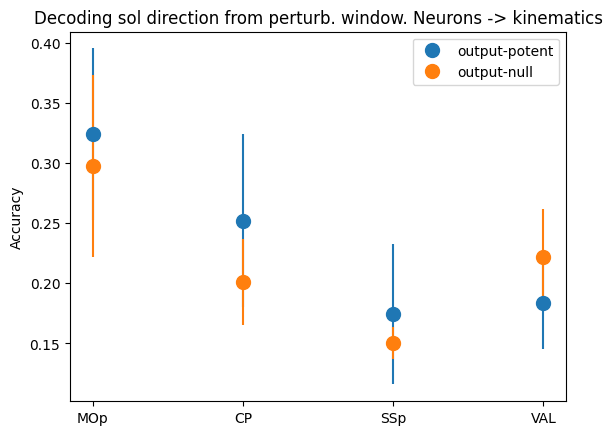

In [150]:
fig, ax = plt.subplots()
ax.errorbar(areas, np.mean(scores_comm_subspace, axis=1), yerr=np.std(scores_comm_subspace, axis=1), fmt='o', markersize=10, label='output-potent')
ax.errorbar(areas, np.mean(scores_null_space, axis=1), yerr=np.std(scores_null_space, axis=1), fmt='o', markersize=10, label='output-null')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_title('Decoding sol direction from perturb. window. Neurons -> kinematics')

### Play around with latencies

In [3]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_05_14_00',
    combine_time_bins=False
)
df_ = handler.df

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
field idx_motion could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/

Resulting SSp_spikes ephys data shape is (NxT): (118, 60000)
Resulting all_spikes ephys data shape is (NxT): (24, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (219, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (100, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (155, 60000)
Resulting CP_spikes ephys data shape is (NxT): (195, 60000)


In [136]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_bhv(df)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -50, rel_end= 150)

In [137]:
targets = df.values_Sol_direction.values.tolist()

In [159]:
from_area = 'SSp_rates'
to_area = 'MOp_rates'
bhv = 'bhv'

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), from_area, to_area)
comm_subspace_ssp_mop = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), to_area, from_area)
comm_subspace_mop_ssp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'MOp_rates', 'bhv')
comm_subspace_mop_bhv = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'MOp_rates', 'CP_rates')
comm_subspace_mop_cp = subspaces.get_output_potent_projector(comm_lr)
comm_null_subspace_mop_cp = subspaces.get_output_null_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'MOp_rates', 'VAL_rates')
comm_subspace_mop_val = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'CP_rates', 'VAL_rates')
comm_subspace_cp_val = subspaces.get_output_potent_projector(comm_lr)
comm_null_subspace_cp_val = subspaces.get_output_null_projector(comm_lr)


# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'VAL_rates', 'MOp_rates')
comm_subspace_val_mop = subspaces.get_output_potent_projector(comm_lr)
comm_null_subspace_val_mop = subspaces.get_output_null_projector(comm_lr)


# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'SSp_rates', 'VAL_rates')
comm_subspace_ssp_val = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'VAL_rates', 'SSp_rates')
comm_subspace_val_ssp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'SSp_rates', 'CP_rates')
comm_subspace_ssp_cp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'bhv', 'SSp_rates')
comm_subspace_bhv_ssp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'VAL_rates', 'CP_rates')
comm_subspace_val_cp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'CP_rates', 'MOp_rates')
comm_subspace_cp_mop = subspaces.get_output_potent_projector(comm_lr)


In [156]:
comm_null_subspace_mop_cp.shape

(178, 6)

In [160]:
projected_ssp_mop = np.array([arr @ comm_subspace_ssp_mop for arr in perturb_td.SSp_rates.values])
projected_mop_ssp = np.array([arr @ comm_subspace_mop_ssp for arr in perturb_td.MOp_rates.values])
projected_mop_bhv = np.array([arr @ comm_subspace_mop_bhv for arr in perturb_td.MOp_rates.values])
projected_mop_cp = np.array([arr @ comm_subspace_mop_cp for arr in perturb_td.MOp_rates.values])
projected_mop_val = np.array([arr @ comm_subspace_mop_val for arr in perturb_td.MOp_rates.values])
projected_cp_val = np.array([arr @ comm_subspace_cp_val for arr in perturb_td.CP_rates.values])
projected_val_mop = np.array([arr @ comm_subspace_val_mop for arr in perturb_td.VAL_rates.values])
projected_val_ssp = np.array([arr @ comm_subspace_val_ssp for arr in perturb_td.VAL_rates.values])
projected_ssp_val = np.array([arr @ comm_subspace_ssp_val for arr in perturb_td.SSp_rates.values])
projected_ssp_cp = np.array([arr @ comm_subspace_ssp_cp for arr in perturb_td.SSp_rates.values])
projected_bhv_ssp = np.array([arr @ comm_subspace_bhv_ssp for arr in perturb_td.bhv.values])
projected_val_cp = np.array([arr @ comm_subspace_val_cp for arr in perturb_td.VAL_rates.values])
projected_cp_mop = np.array([arr @ comm_subspace_cp_mop for arr in perturb_td.CP_rates.values])


null_mop_cp = np.array([arr @ comm_null_subspace_mop_cp for arr in perturb_td.MOp_rates.values])
null_cp_val = np.array([arr @ comm_null_subspace_cp_val for arr in perturb_td.CP_rates.values])
null_val_mop = np.array([arr @ comm_null_subspace_val_mop for arr in perturb_td.VAL_rates.values])


bhv = np.stack(perturb_td.bhv.values)
mop = np.stack(perturb_td.MOp_rates.values)
ssp = np.stack(perturb_td.SSp_rates.values)
cp = np.stack(perturb_td.CP_rates.values)
val = np.stack(perturb_td.VAL_rates.values)





In [161]:
k=5
scores_ssp_mop, times = decode.moving_window_decoding(
    projected_ssp_mop,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_mop_ssp, times = decode.moving_window_decoding(
    projected_mop_ssp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_mop_bhv, times = decode.moving_window_decoding(
    projected_mop_bhv,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_bhv, times = decode.moving_window_decoding(
    bhv,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_mop_cp, times = decode.moving_window_decoding(
    projected_mop_cp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_mop_val, times = decode.moving_window_decoding(
    projected_mop_val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_cp_val, times = decode.moving_window_decoding(
    projected_cp_val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_val_mop, times = decode.moving_window_decoding(
    projected_val_mop,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_ssp_val, times = decode.moving_window_decoding(
    projected_ssp_val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_val_ssp, times = decode.moving_window_decoding(
    projected_val_ssp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_ssp_cp, times = decode.moving_window_decoding(
    projected_ssp_cp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_bhv_ssp, times = decode.moving_window_decoding(
    projected_bhv_ssp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

In [162]:
scores_mop_val, times = decode.moving_window_decoding(
    projected_mop_val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_val_cp, times = decode.moving_window_decoding(
    projected_val_cp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_cp_mop, times = decode.moving_window_decoding(
    projected_cp_mop,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

# scores_null_val_mop, times = decode.moving_window_decoding(
#     null_val_mop,
#     targets,
#     window_length_bin=10,
#     step_bin=1,
#     k=k
# )

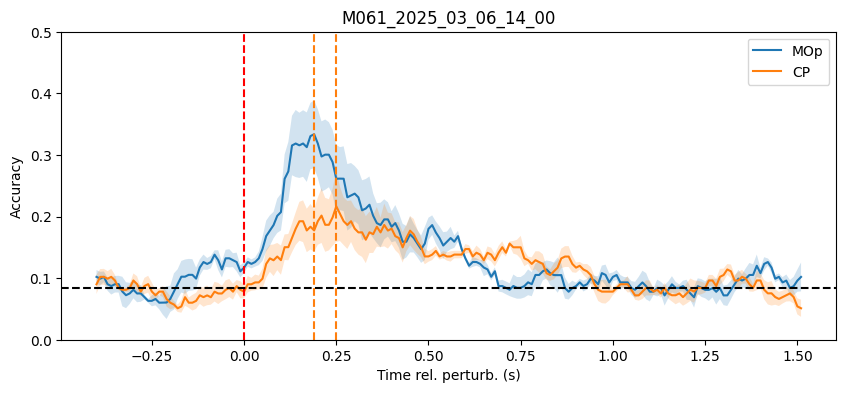

In [175]:
fig, ax = plt.subplots(figsize=(10, 4))
# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_mop, errorStat=scipy.stats.sem, label='SSp->MOp')
# ax.axvline(x=times[np.argmax(scores_ssp_mop.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_ssp, errorStat=scipy.stats.sem, label='MOp->SSp')
# ax.axvline(x=times[np.argmax(scores_mop_ssp.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_bhv, errorStat=scipy.stats.sem, label='MOp->Bhv')
# ax.axvline(x=times[np.argmax(scores_mop_bhv.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_bhv, errorStat=scipy.stats.sem, label='Bhv')
# ax.axvline(x=times[np.argmax(scores_bhv.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_bhv_ssp, errorStat=scipy.stats.sem, label='Bhv->SSp')
# ax.axvline(x=times[np.argmax(scores_bhv_ssp.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')


# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_val, errorStat=scipy.stats.sem, label='MOp->VAL')
# ax.axvline(x=times[np.argmax(scores_mop_val.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_val_cp, errorStat=scipy.stats.sem, label='VAL->CP')
# ax.axvline(x=times[np.argmax(scores_val_cp.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_cp_mop, errorStat=scipy.stats.sem, label='CP->MOp')
# ax.axvline(x=times[np.argmax(scores_cp_mop.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_cp, errorStat=scipy.stats.sem, label='SSp->CP')
# ax.axvline(x=times[np.argmax(scores_ssp_cp.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')


# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_val, errorStat=scipy.stats.sem, label='MOp->VAL')
# ax.axvline(x=times[np.argmax(scores_mop_val.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_null_cp_val, errorStat=scipy.stats.sem, label='CP->VAL')
# ax.axvline(x=times[np.argmax(scores_null_cp_val.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')

vizutils.shaded_errorbar(ax, times-0.5, scores_mop, errorStat=scipy.stats.sem, label='MOp')
ax.axvline(x=times[np.argmax(scores_mop.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')

vizutils.shaded_errorbar(ax, times-0.5, scores_cp, errorStat=scipy.stats.sem, label='CP')
ax.axvline(x=times[np.argmax(scores_cp.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_val_mop, errorStat=scipy.stats.sem, label='VAL->MOp')
# ax.axvline(x=times[np.argmax(scores_val_mop.mean(axis=-1))]-0.5, color='tab:red', linestyle='dashed')

ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 0.5)
ax.legend()
# ax.set_xlim(0, 0.5)
ax.set_title(f'{handler.session}')
plt.show()

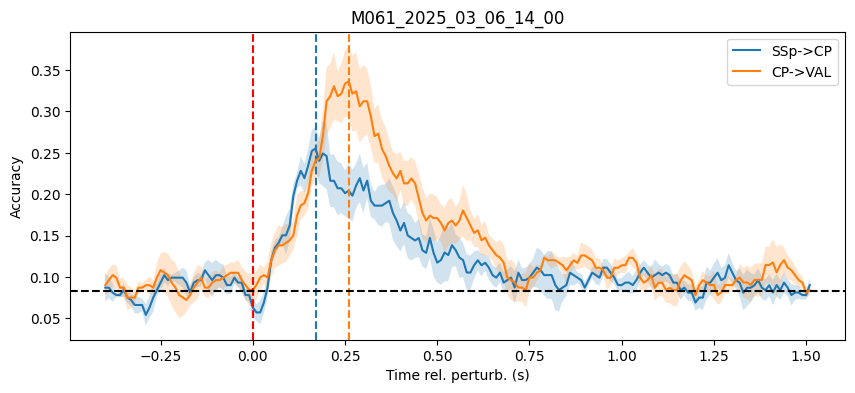

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_mop, errorStat=scipy.stats.sem, label='SSp->MOp')
# ax.axvline(x=times[np.argmax(scores_ssp_mop.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_ssp, errorStat=scipy.stats.sem, label='MOp->SSp')
# ax.axvline(x=times[np.argmax(scores_mop_ssp.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_bhv, errorStat=scipy.stats.sem, label='MOp->Bhv')
# ax.axvline(x=times[np.argmax(scores_mop_bhv.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_bhv, errorStat=scipy.stats.sem, label='Bhv')
# ax.axvline(x=times[np.argmax(scores_bhv.mean(axis=-1))]-1, color='tab:orange', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_cp, errorStat=scipy.stats.sem, label='MOp->CP')
# ax.axvline(x=times[np.argmax(scores_mop_cp.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_val, errorStat=scipy.stats.sem, label='MOp->VAL')
# ax.axvline(x=times[np.argmax(scores_mop_val.mean(axis=-1))]-0.5, color='tab:green', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_cp, errorStat=scipy.stats.sem, label='SSp->CP')
# ax.axvline(x=times[np.argmax(scores_ssp_cp.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_cp_val, errorStat=scipy.stats.sem, label='CP->VAL')
# ax.axvline(x=times[np.argmax(scores_cp_val.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_val_mop, errorStat=scipy.stats.sem, label='VAL->MOp')
# ax.axvline(x=times[np.argmax(scores_val_mop.mean(axis=-1))]-0.5, color='tab:green', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_val, errorStat=scipy.stats.sem, label='VAL->SSp')
# ax.axvline(x=times[np.argmax(scores_ssp_val.mean(axis=-1))]-0.5, color='tab:green', linestyle='dashed')

ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
# ax.set_ylim(0, 0.45)
ax.legend()
# ax.set_xlim(0, 0.5)
ax.set_title(f'{handler.session}')
plt.show()

## M063

In [130]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M063_2025_03_14_15_30',
    combine_time_bins=False
)
df_ = handler.df

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
field idx_motion could not be converted to int.
field values_Sol_direction could not be converted to int.
field idx_Sol_direction could not be converted to int.
field values_Sol_duration could not be converted to int.
field idx_Sol_duration could not be converted to int.
field idx_sol_on could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
fie

/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/

Resulting VAL_spikes ephys data shape is (NxT): (260, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (92, 60000)
Resulting all_spikes ephys data shape is (NxT): (38, 60000)
Resulting CP_spikes ephys data shape is (NxT): (329, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (161, 60000)


In [131]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
# df = dt.add_bhv(df)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -50, rel_end= 150)
targets = df.values_Sol_direction.values.tolist()[:-1]

In [132]:
from_area = 'SSp_rates'
to_area = 'MOp_rates'
bhv = 'bhv'

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), from_area, to_area)
comm_subspace_ssp_mop = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), to_area, from_area)
comm_subspace_mop_ssp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
# comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'MOp_rates', 'bhv')
# comm_subspace_mop_bhv = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'MOp_rates', 'CP_rates')
comm_subspace_mop_cp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'MOp_rates', 'VAL_rates')
comm_subspace_mop_val = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'CP_rates', 'VAL_rates')
comm_subspace_cp_val = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'VAL_rates', 'MOp_rates')
comm_subspace_val_mop = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'SSp_rates', 'VAL_rates')
comm_subspace_ssp_val = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'VAL_rates', 'SSp_rates')
comm_subspace_val_ssp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'SSp_rates', 'CP_rates')
comm_subspace_ssp_cp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
# comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'bhv', 'SSp_rates')
# comm_subspace_bhv_ssp = subspaces.get_output_potent_projector(comm_lr)

In [133]:
projected_ssp_mop = np.array([arr @ comm_subspace_ssp_mop for arr in perturb_td.SSp_rates.values])
projected_mop_ssp = np.array([arr @ comm_subspace_mop_ssp for arr in perturb_td.MOp_rates.values])
# projected_mop_bhv = np.array([arr @ comm_subspace_mop_bhv for arr in perturb_td.MOp_rates.values])
projected_mop_cp = np.array([arr @ comm_subspace_mop_cp for arr in perturb_td.MOp_rates.values])
projected_mop_val = np.array([arr @ comm_subspace_mop_val for arr in perturb_td.MOp_rates.values])
projected_cp_val = np.array([arr @ comm_subspace_cp_val for arr in perturb_td.CP_rates.values])
projected_val_mop = np.array([arr @ comm_subspace_val_mop for arr in perturb_td.VAL_rates.values])
projected_val_ssp = np.array([arr @ comm_subspace_val_ssp for arr in perturb_td.VAL_rates.values])
projected_ssp_val = np.array([arr @ comm_subspace_ssp_val for arr in perturb_td.SSp_rates.values])
projected_ssp_cp = np.array([arr @ comm_subspace_ssp_cp for arr in perturb_td.SSp_rates.values])
# projected_bhv_ssp = np.array([arr @ comm_subspace_bhv_ssp for arr in perturb_td.bhv.values])

# bhv = np.stack(perturb_td.bhv.values)


In [134]:
k=5
scores_ssp_mop, times = decode.moving_window_decoding(
    projected_ssp_mop,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_mop_ssp, times = decode.moving_window_decoding(
    projected_mop_ssp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

# scores_mop_bhv, times = decode.moving_window_decoding(
#     projected_mop_bhv,
#     targets,
#     window_length_bin=10,
#     step_bin=1,
#     k=k
# )

# scores_bhv, times = decode.moving_window_decoding(
#     bhv,
#     targets,
#     window_length_bin=10,
#     step_bin=1,
#     k=k
# )

scores_mop_cp, times = decode.moving_window_decoding(
    projected_mop_cp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_mop_val, times = decode.moving_window_decoding(
    projected_mop_val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_cp_val, times = decode.moving_window_decoding(
    projected_cp_val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_val_mop, times = decode.moving_window_decoding(
    projected_val_mop,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_ssp_val, times = decode.moving_window_decoding(
    projected_ssp_val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_val_ssp, times = decode.moving_window_decoding(
    projected_val_ssp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_ssp_cp, times = decode.moving_window_decoding(
    projected_ssp_cp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

# scores_bhv_ssp, times = decode.moving_window_decoding(
#     projected_bhv_ssp,
#     targets,
#     window_length_bin=10,
#     step_bin=1,
#     k=k
# )

ValueError: Found input variables with inconsistent numbers of samples: [337, 336]

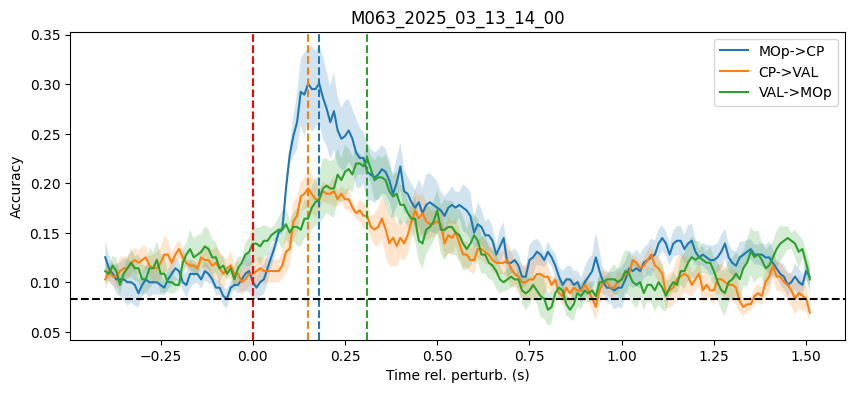

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_mop, errorStat=scipy.stats.sem, label='SSp->MOp')
# ax.axvline(x=times[np.argmax(scores_ssp_mop.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_ssp, errorStat=scipy.stats.sem, label='MOp->SSp')
# ax.axvline(x=times[np.argmax(scores_mop_ssp.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_bhv, errorStat=scipy.stats.sem, label='MOp->Bhv')
# ax.axvline(x=times[np.argmax(scores_mop_bhv.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_bhv, errorStat=scipy.stats.sem, label='Bhv')
# ax.axvline(x=times[np.argmax(scores_bhv.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_bhv_ssp, errorStat=scipy.stats.sem, label='Bhv->SSp')
# ax.axvline(x=times[np.argmax(scores_bhv_ssp.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')


vizutils.shaded_errorbar(ax, times-0.5, scores_mop_cp, errorStat=scipy.stats.sem, label='MOp->CP')
ax.axvline(x=times[np.argmax(scores_mop_cp.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_cp, errorStat=scipy.stats.sem, label='SSp->CP')
# ax.axvline(x=times[np.argmax(scores_ssp_cp.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')


# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_val, errorStat=scipy.stats.sem, label='MOp->VAL')
# ax.axvline(x=times[np.argmax(scores_mop_val.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

vizutils.shaded_errorbar(ax, times-0.5, scores_cp_val, errorStat=scipy.stats.sem, label='CP->VAL')
ax.axvline(x=times[np.argmax(scores_cp_val.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')

vizutils.shaded_errorbar(ax, times-0.5, scores_val_mop, errorStat=scipy.stats.sem, label='VAL->MOp')
ax.axvline(x=times[np.argmax(scores_val_mop.mean(axis=-1))]-0.5, color='tab:green', linestyle='dashed')

ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
# ax.set_ylim(0, 0.5)
ax.legend()
# ax.set_xlim(0, 0.5)
ax.set_title(f'{handler.session}')
plt.show()

## Compare with pca

In [ ]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_05_14_00',
    combine_time_bins=False
)
df_ = handler.df

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field all_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/

Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [98]:
df = dt.add_pca_df(df_, n_components=None)
df = dt.add_bhv(df)
df = pyal.select_trials(df, df.trial_name == 'trial')
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -50, rel_end= 150)

In [50]:
bhv = np.stack(perturb_td.bhv.values)
mop = np.stack(perturb_td.MOp_rates_pca.values)
ssp = np.stack(perturb_td.SSp_rates_pca.values)
cp = np.stack(perturb_td.CP_rates_pca.values)
val = np.stack(perturb_td.VAL_rates_pca.values)
targets = df.values_Sol_direction.values.tolist()

In [51]:
k = 5
scores = {}
signals = ['bhv', 'MOp_rates_pca', 'SSp_rates_pca', 'CP_rates_pca', 'VAL_rates_pca']
for signal in signals:
    scores_, times = decode.moving_window_decoding(
        np.stack(perturb_td[signal].values),
        targets,
        window_length_bin=1,
        step_bin=1,
        k=k
    )
    scores[signal] = scores_

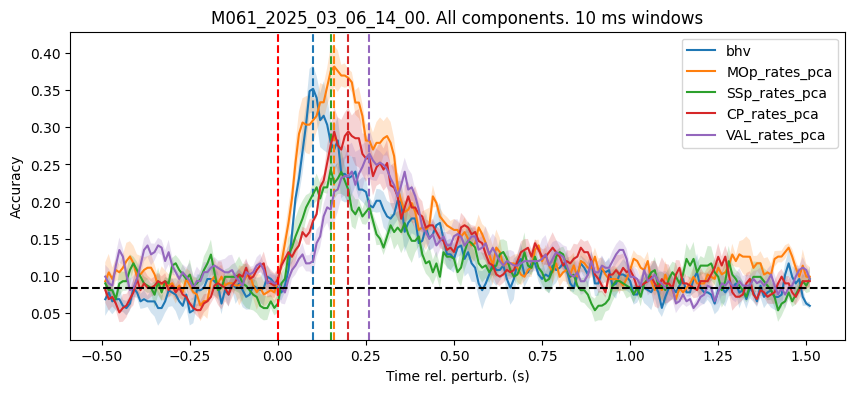

In [52]:
fig, ax = plt.subplots(figsize=(10, 4))
for score_key, score in scores.items():
    line, _ = vizutils.shaded_errorbar(ax, times-0.5, score, errorStat=scipy.stats.sem, label=score_key)
    ax.axvline(x=times[np.argmax(score.mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')
ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
# ax.set_ylim(0, 0.5)
ax.legend()
# ax.set_xlim(0, 0.5)
ax.set_title(f'{handler.session}. All components. 10 ms windows')
plt.show()

In [64]:
cp.shape

(333, 201, 172)

In [108]:


mop_flat = np.reshape(mop,(mop.shape[0]*mop.shape[1], -1))
cp_flat = np.reshape(cp,(cp.shape[0]*cp.shape[1], -1))

comm_model_mop_cp = subspaces.ReducedRankCommSubspace(
    rank=10,
    reg=0.01
)
comm_model_mop_cp.fit(mop_flat, cp_flat)
subspace_mop_cp = comm_model_mop_cp.coef_

In [109]:
subspace_mop_cp.shape

(172, 178)

In [110]:
proj_mop_pca_rates = np.array([arr @ subspace_mop_cp.T for arr in mop])

In [ ]:
scores_, times = decode.moving_window_decoding(
    proj_mop_pca_rates,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

(333, 201, 10)

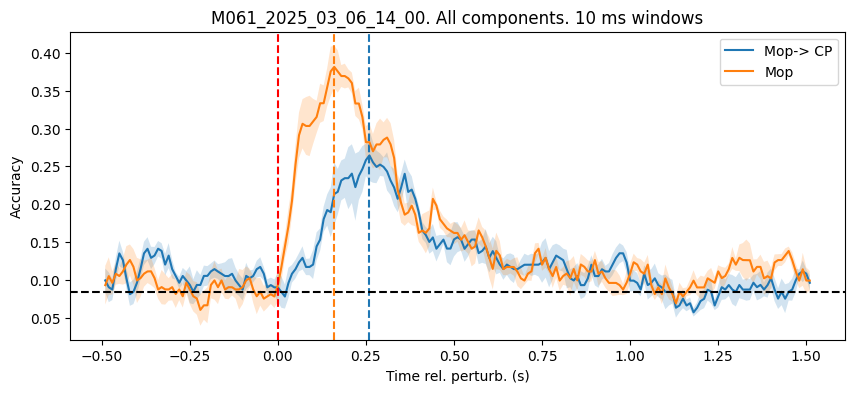

In [76]:
fig, ax = plt.subplots(figsize=(10, 4))
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores_, errorStat=scipy.stats.sem, label='Mop-> CP')
ax.axvline(x=times[np.argmax(scores_.mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['MOp_rates_pca'], errorStat=scipy.stats.sem, label='Mop')
ax.axvline(x=times[np.argmax(scores['MOp_rates_pca'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')


ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
# ax.set_ylim(0, 0.5)
ax.legend()
# ax.set_xlim(0, 0.5)
ax.set_title(f'{handler.session}. All components. 10 ms windows')
plt.show()

In [154]:
k = 5
scores = {}
signals = ['bhv', 'MOp_rates_pca', 'SSp_rates_pca', 'CP_rates_pca', 'VAL_rates_pca']
for from_area in signals:
    scores[from_area] = {}
    pcs_area_x_ = np.stack(perturb_td[from_area].values)
    pcs_area_x = np.reshape(pcs_area_x_,(pcs_area_x_.shape[0]*pcs_area_x_.shape[1], -1))

    for to_area in signals:
        
        pcs_area_y_ = np.stack(perturb_td[to_area].values)
        pcs_area_y = np.reshape(pcs_area_y_,(pcs_area_y_.shape[0]*pcs_area_y_.shape[1], -1))

        comm_model = subspaces.ReducedRankCommSubspace(
            rank=10,
            reg=0.01
        )

        comm_model.fit(pcs_area_x, pcs_area_y)
        comm_subspace = subspaces.get_output_potent_projector(comm_model)
        proj_comm_pc_rates = np.array([arr @ comm_subspace for arr in pcs_area_x_])

        scores_, times = decode.moving_window_decoding(
            proj_comm_pc_rates,
            targets,
            window_length_bin=10,
            step_bin=1,
            k=k
        )
        scores[from_area][to_area] = scores_

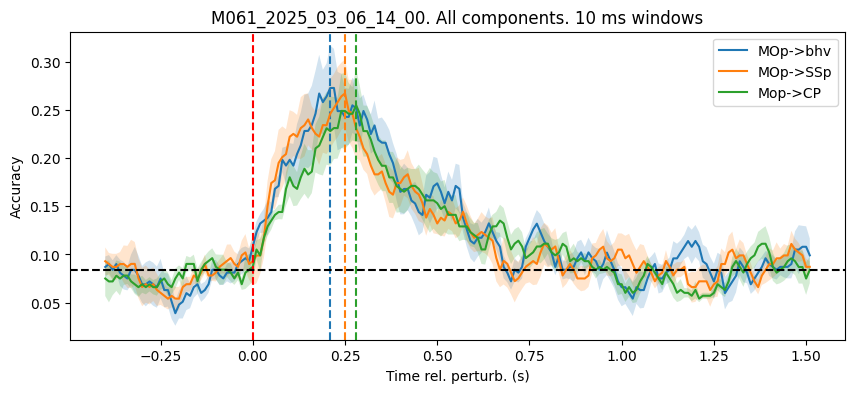

In [172]:
fig, ax = plt.subplots(figsize=(10, 4))
errorStat = scipy.stats.sem

# line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['bhv']['SSp_rates_pca'], errorStat=errorStat, label='Bhv->SSp')
# ax.axvline(x=times[np.argmax(scores['bhv']['SSp_rates_pca'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

# line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['bhv']['MOp_rates_pca'], errorStat=errorStat, label='Bhv->MOp')
# ax.axvline(x=times[np.argmax(scores['bhv']['MOp_rates_pca'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

# line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['bhv']['CP_rates_pca'], errorStat=errorStat, label='Bhv->CP')
# ax.axvline(x=times[np.argmax(scores['bhv']['CP_rates_pca'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

# line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['bhv']['VAL_rates_pca'], errorStat=errorStat, label='Bhv->VAL')
# ax.axvline(x=times[np.argmax(scores['bhv']['VAL_rates_pca'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['MOp_rates_pca']['bhv'], errorStat=errorStat, label='MOp->bhv')
ax.axvline(x=times[np.argmax(scores['MOp_rates_pca']['bhv'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['MOp_rates_pca']['SSp_rates_pca'], errorStat=errorStat, label='MOp->SSp')
ax.axvline(x=times[np.argmax(scores['MOp_rates_pca']['SSp_rates_pca'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')


line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['MOp_rates_pca']['CP_rates_pca'], errorStat=errorStat, label='Mop->CP')
ax.axvline(x=times[np.argmax(scores['MOp_rates_pca']['CP_rates_pca'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

# line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['CP_rates_pca']['VAL_rates_pca'], errorStat=errorStat, label='CP->VAL')
# ax.axvline(x=times[np.argmax(scores['CP_rates_pca']['VAL_rates_pca'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

# line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['VAL']['CP'], errorStat=errorStat, label='VAL->CP')
# ax.axvline(x=times[np.argmax(scores['VAL']['CP'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

# line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['CP']['MOp'], errorStat=errorStat, label='CP->MOp')
# ax.axvline(x=times[np.argmax(scores['CP']['MOp'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

# line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['VAL_rates_pca']['MOp_rates_pca'], errorStat=errorStat, label='VAL->MOp')
# ax.axvline(x=times[np.argmax(scores['VAL_rates_pca']['MOp_rates_pca'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

# # line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['VAL']['SSp'], errorStat=errorStat, label='VAL->SSp')
# ax.axvline(x=times[np.argmax(scores['VAL']['SSp'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

# line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores['MOp_rates_pca']['VAL_rates_pca'], errorStat=errorStat, label='MOp->VAL')
# ax.axvline(x=times[np.argmax(scores['MOp_rates_pca']['VAL_rates_pca'].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')


# line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores_, errorStat=scipy.stats.sem, label='Mop-> CP')
# ax.axvline(x=times[np.argmax(scores_.mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')


ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
# ax.set_ylim(0, 0.5)
ax.legend()
# ax.set_xlim(0, 0.5)
ax.set_title(f'{handler.session}. All components. 10 ms windows')
plt.show()

In [200]:
def plot_comm_subspaces(ax, scores, pairs, errorStat = scipy.stats.sem, title='All components. 10 ms windows'):

    for from_area, to_area in pairs:
        line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores[from_area][to_area], errorStat=errorStat, label=f'{from_area}-> {to_area}')
    
        ax.axvline(x=times[np.argmax(scores[from_area][to_area].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

    ax.axvline(x=0, color='r', linestyle='dashed')
    ax.axhline(y=1/12, color='k', linestyle='dashed')
    ax.set_xlabel('Time rel. perturb. (s)')
    ax.set_ylabel('Accuracy')
    # ax.set_ylim(0, 0.5)
    ax.legend()
    # ax.set_xlim(0, 0.5)
    ax.set_title(f'{handler.session}. {title}')
    

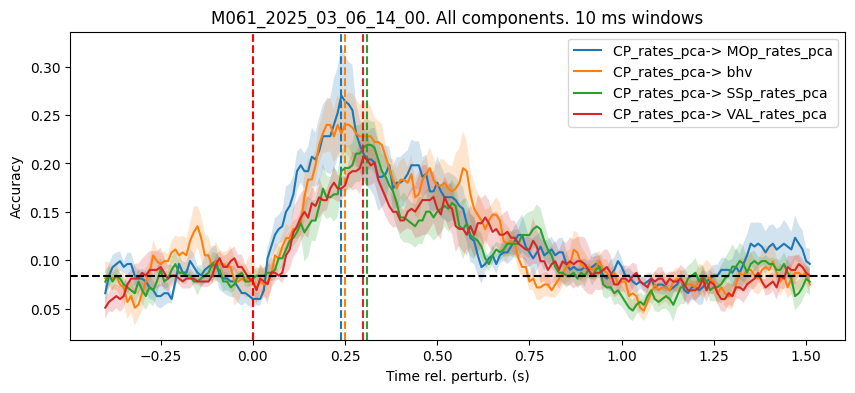

In [ ]:
pairs = [
    ('MOp_rates_pca', 'bhv'),
    ('MOp_rates_pca', 'SSp_rates_pca'),
    ('MOp_rates_pca', 'CP_rates_pca'),
    ('MOp_rates_pca', 'VAL_rates_pca')
]

pairs = [
    ('bhv', 'MOp_rates_pca'),
    ('bhv', 'SSp_rates_pca'),
    ('bhv', 'CP_rates_pca'),
    ('bhv', 'VAL_rates_pca')
]

pairs = [
    ('SSp_rates_pca', 'MOp_rates_pca'),
    ('SSp_rates_pca', 'bhv'),
    ('SSp_rates_pca', 'CP_rates_pca'),
    ('SSp_rates_pca', 'VAL_rates_pca')
]

pairs = [
    ('CP_rates_pca', 'MOp_rates_pca'),
    ('CP_rates_pca', 'bhv'),
    ('CP_rates_pca', 'SSp_rates_pca'),
    ('CP_rates_pca', 'VAL_rates_pca')
]

# pairs = [
#     ('VAL_rates_pca', 'MOp_rates_pca'),
#     ('VAL_rates_pca', 'bhv'),
#     ('VAL_rates_pca', 'SSp_rates_pca'),
#     ('VAL_rates_pca', 'CP_rates_pca')
# ]


plot_comm_subspaces(scores, pairs)

In [ ]:
k = 5
scores_null = {}
signals = ['bhv', 'MOp_rates_pca', 'SSp_rates_pca', 'CP_rates_pca', 'VAL_rates_pca']
for from_area in signals:
    scores_null[from_area] = {}
    pcs_area_x_ = np.stack(perturb_td[from_area].values)
    pcs_area_x = np.reshape(pcs_area_x_,(pcs_area_x_.shape[0]*pcs_area_x_.shape[1], -1))

    for to_area in signals:
        
        pcs_area_y_ = np.stack(perturb_td[to_area].values)
        pcs_area_y = np.reshape(pcs_area_y_,(pcs_area_y_.shape[0]*pcs_area_y_.shape[1], -1))

        comm_model = subspaces.ReducedRankCommSubspace(
            rank=10,
            reg=0.01
        )

        comm_model.fit(pcs_area_x, pcs_area_y)
        comm_subspace = subspaces.get_output_null_projector(comm_model)
        proj_comm_pc_rates = np.array([arr @ comm_subspace for arr in pcs_area_x_])

        scores_, times = decode.moving_window_decoding(
            proj_comm_pc_rates,
            targets,
            window_length_bin=10,
            step_bin=1,
            k=k
        )
        scores_null[from_area][to_area] = scores_

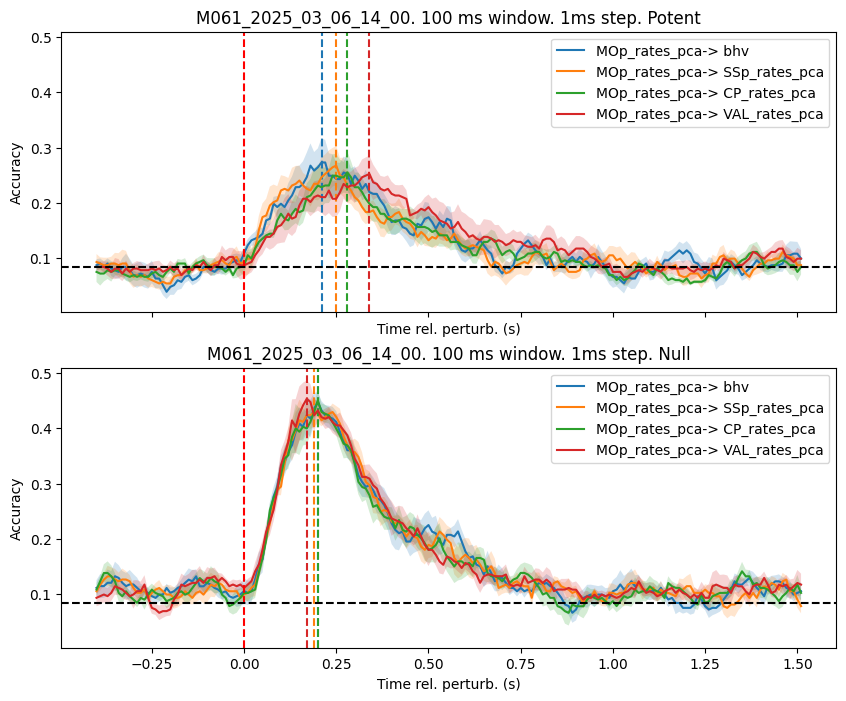

In [204]:
pairs = [
    ('MOp_rates_pca', 'bhv'),
    ('MOp_rates_pca', 'SSp_rates_pca'),
    ('MOp_rates_pca', 'CP_rates_pca'),
    ('MOp_rates_pca', 'VAL_rates_pca')
]

# pairs = [
#     ('bhv', 'MOp_rates_pca'),
#     ('bhv', 'SSp_rates_pca'),
#     ('bhv', 'CP_rates_pca'),
#     ('bhv', 'VAL_rates_pca')
# ]

# pairs = [
#     ('SSp_rates_pca', 'MOp_rates_pca'),
#     ('SSp_rates_pca', 'bhv'),
#     ('SSp_rates_pca', 'CP_rates_pca'),
#     ('SSp_rates_pca', 'VAL_rates_pca')
# ]

# pairs = [
#     ('CP_rates_pca', 'MOp_rates_pca'),
#     ('CP_rates_pca', 'bhv'),
#     ('CP_rates_pca', 'SSp_rates_pca'),
#     ('CP_rates_pca', 'VAL_rates_pca')
# ]

# pairs = [
#     ('VAL_rates_pca', 'MOp_rates_pca'),
#     ('VAL_rates_pca', 'bhv'),
#     ('VAL_rates_pca', 'SSp_rates_pca'),
#     ('VAL_rates_pca', 'CP_rates_pca')
# ]
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex='all', sharey='all')

plot_comm_subspaces(axes[0], scores, pairs, title='100 ms window. 1ms step. Potent')
plot_comm_subspaces(axes[1], scores_null, pairs, title='100 ms window. 1ms step. Null')

In [211]:
k = 5
rank = 15
scores_null_rank20 = {}
scores_potent_rank20 = {}

signals = ['bhv', 'MOp_rates_pca', 'SSp_rates_pca', 'CP_rates_pca', 'VAL_rates_pca']
for from_area in signals:
    scores_null_rank20[from_area] = {}
    scores_potent_rank20[from_area] = {}
    pcs_area_x_ = np.stack(perturb_td[from_area].values)
    pcs_area_x = np.reshape(pcs_area_x_,(pcs_area_x_.shape[0]*pcs_area_x_.shape[1], -1))

    for to_area in signals:
        
        pcs_area_y_ = np.stack(perturb_td[to_area].values)
        pcs_area_y = np.reshape(pcs_area_y_,(pcs_area_y_.shape[0]*pcs_area_y_.shape[1], -1))

        comm_model = subspaces.ReducedRankCommSubspace(
            rank=rank,
            reg=0.01
        )

        comm_model.fit(pcs_area_x, pcs_area_y)

        # Output null
        comm_subspace = subspaces.get_output_null_projector(comm_model)
        proj_comm_pc_rates = np.array([arr @ comm_subspace for arr in pcs_area_x_])

        scores_, times = decode.moving_window_decoding(
            proj_comm_pc_rates,
            targets,
            window_length_bin=10,
            step_bin=1,
            k=k
        )
        scores_null_rank20[from_area][to_area] = scores_

        # Output potent
        comm_subspace = subspaces.get_output_potent_projector(comm_model)
        proj_comm_pc_rates = np.array([arr @ comm_subspace for arr in pcs_area_x_])

        scores_, times = decode.moving_window_decoding(
            proj_comm_pc_rates,
            targets,
            window_length_bin=10,
            step_bin=1,
            k=k
        )
        scores_potent_rank20[from_area][to_area] = scores_

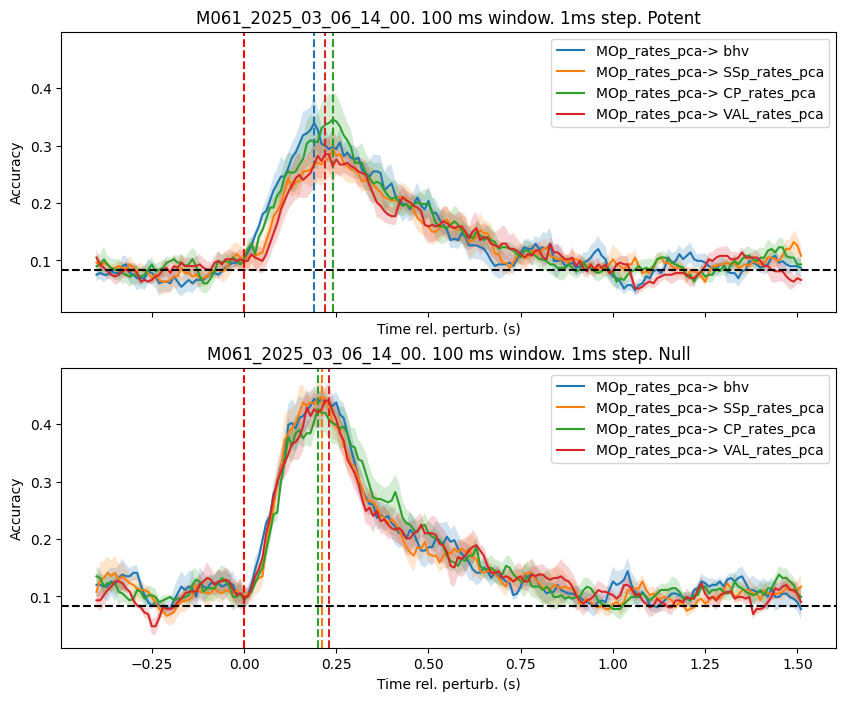

In [208]:
pairs = [
    ('MOp_rates_pca', 'bhv'),
    ('MOp_rates_pca', 'SSp_rates_pca'),
    ('MOp_rates_pca', 'CP_rates_pca'),
    ('MOp_rates_pca', 'VAL_rates_pca')
]

# pairs = [
#     ('bhv', 'MOp_rates_pca'),
#     ('bhv', 'SSp_rates_pca'),
#     ('bhv', 'CP_rates_pca'),
#     ('bhv', 'VAL_rates_pca')
# ]

# pairs = [
#     ('SSp_rates_pca', 'MOp_rates_pca'),
#     ('SSp_rates_pca', 'bhv'),
#     ('SSp_rates_pca', 'CP_rates_pca'),
#     ('SSp_rates_pca', 'VAL_rates_pca')
# ]

# pairs = [
#     ('CP_rates_pca', 'MOp_rates_pca'),
#     ('CP_rates_pca', 'bhv'),
#     ('CP_rates_pca', 'SSp_rates_pca'),
#     ('CP_rates_pca', 'VAL_rates_pca')
# ]

# pairs = [
#     ('VAL_rates_pca', 'MOp_rates_pca'),
#     ('VAL_rates_pca', 'bhv'),
#     ('VAL_rates_pca', 'SSp_rates_pca'),
#     ('VAL_rates_pca', 'CP_rates_pca')
# ]
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex='all', sharey='all')

plot_comm_subspaces(axes[0], scores_potent_rank20, pairs, title='100 ms window. 1ms step. Potent')
plot_comm_subspaces(axes[1], scores_null_rank20, pairs, title='100 ms window. 1ms step. Null')

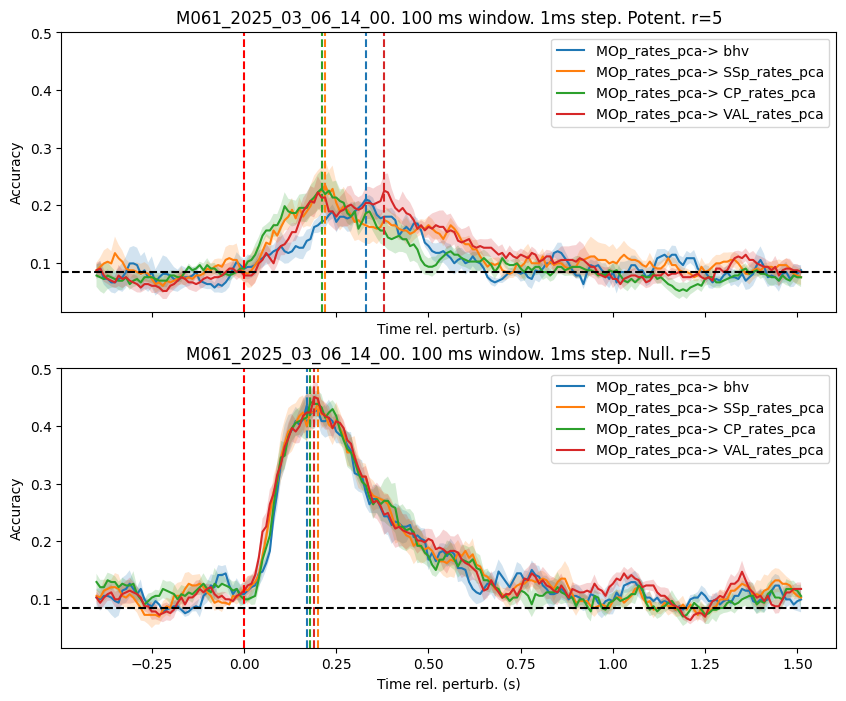

In [210]:
pairs = [
    ('MOp_rates_pca', 'bhv'),
    ('MOp_rates_pca', 'SSp_rates_pca'),
    ('MOp_rates_pca', 'CP_rates_pca'),
    ('MOp_rates_pca', 'VAL_rates_pca')
]

# pairs = [
#     ('bhv', 'MOp_rates_pca'),
#     ('bhv', 'SSp_rates_pca'),
#     ('bhv', 'CP_rates_pca'),
#     ('bhv', 'VAL_rates_pca')
# ]

# pairs = [
#     ('SSp_rates_pca', 'MOp_rates_pca'),
#     ('SSp_rates_pca', 'bhv'),
#     ('SSp_rates_pca', 'CP_rates_pca'),
#     ('SSp_rates_pca', 'VAL_rates_pca')
# ]

# pairs = [
#     ('CP_rates_pca', 'MOp_rates_pca'),
#     ('CP_rates_pca', 'bhv'),
#     ('CP_rates_pca', 'SSp_rates_pca'),
#     ('CP_rates_pca', 'VAL_rates_pca')
# ]

# pairs = [
#     ('VAL_rates_pca', 'MOp_rates_pca'),
#     ('VAL_rates_pca', 'bhv'),
#     ('VAL_rates_pca', 'SSp_rates_pca'),
#     ('VAL_rates_pca', 'CP_rates_pca')
# ]
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex='all', sharey='all')

plot_comm_subspaces(axes[0], scores_potent_rank20, pairs, title='100 ms window. 1ms step. Potent. r=5')
plot_comm_subspaces(axes[1], scores_null_rank20, pairs, title='100 ms window. 1ms step. Null. r=5')

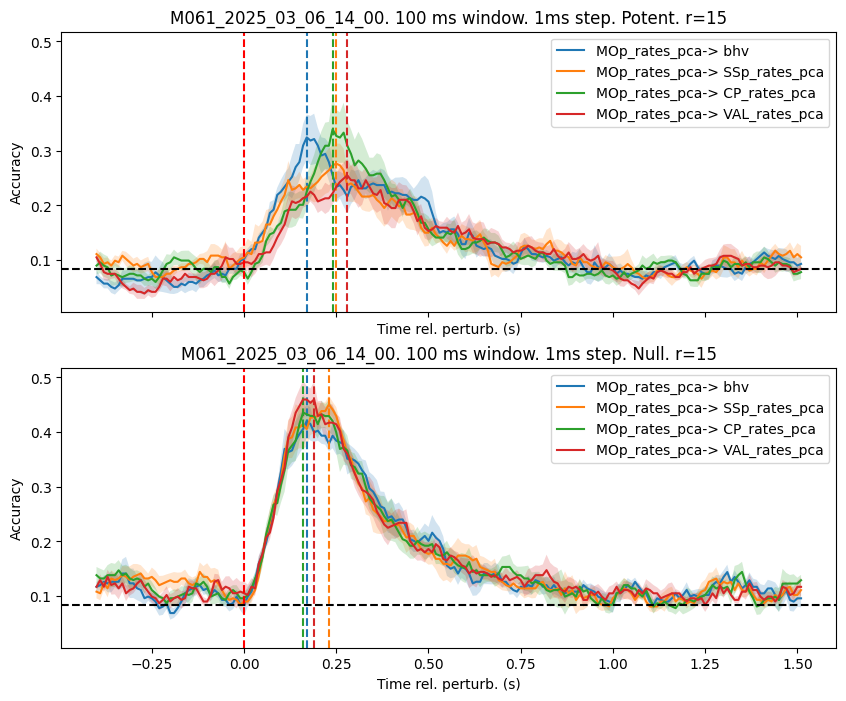

In [212]:
pairs = [
    ('MOp_rates_pca', 'bhv'),
    ('MOp_rates_pca', 'SSp_rates_pca'),
    ('MOp_rates_pca', 'CP_rates_pca'),
    ('MOp_rates_pca', 'VAL_rates_pca')
]

# pairs = [
#     ('bhv', 'MOp_rates_pca'),
#     ('bhv', 'SSp_rates_pca'),
#     ('bhv', 'CP_rates_pca'),
#     ('bhv', 'VAL_rates_pca')
# ]

# pairs = [
#     ('SSp_rates_pca', 'MOp_rates_pca'),
#     ('SSp_rates_pca', 'bhv'),
#     ('SSp_rates_pca', 'CP_rates_pca'),
#     ('SSp_rates_pca', 'VAL_rates_pca')
# ]

# pairs = [
#     ('CP_rates_pca', 'MOp_rates_pca'),
#     ('CP_rates_pca', 'bhv'),
#     ('CP_rates_pca', 'SSp_rates_pca'),
#     ('CP_rates_pca', 'VAL_rates_pca')
# ]

# pairs = [
#     ('VAL_rates_pca', 'MOp_rates_pca'),
#     ('VAL_rates_pca', 'bhv'),
#     ('VAL_rates_pca', 'SSp_rates_pca'),
#     ('VAL_rates_pca', 'CP_rates_pca')
# ]
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex='all', sharey='all')

plot_comm_subspaces(axes[0], scores_potent_rank20, pairs, title='100 ms window. 1ms step. Potent. r=15')
plot_comm_subspaces(axes[1], scores_null_rank20, pairs, title='100 ms window. 1ms step. Null. r=15')

## New attempt

In [3]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_05_14_00',
    combine_time_bins=False
)
df_ = handler.df

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
field idx_motion could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/

Resulting SSp_spikes ephys data shape is (NxT): (118, 60000)
Resulting all_spikes ephys data shape is (NxT): (24, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (219, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (100, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (155, 60000)
Resulting CP_spikes ephys data shape is (NxT): (195, 60000)


In [ ]:
df = dt.add_pca_df(df_, n_components=30)
df = pyal.select_trials(df, df.trial_name == 'trial')
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -50, rel_end= 150)
targets = df.values_Sol_direction.values.tolist()

In [82]:
mop = np.concatenate(df.MOp_rates_pca.values)
cp = np.concatenate(df.CP_rates_pca.values)

mop_perturb_td = np.concatenate(perturb_td.MOp_rates_pca.values)


In [83]:
comm_model = subspaces.ReducedRankCommSubspace(rank=15, reg=0.05)
comm_model.fit(mop, cp)

(30, 30)


<BarContainer object of 30 artists>

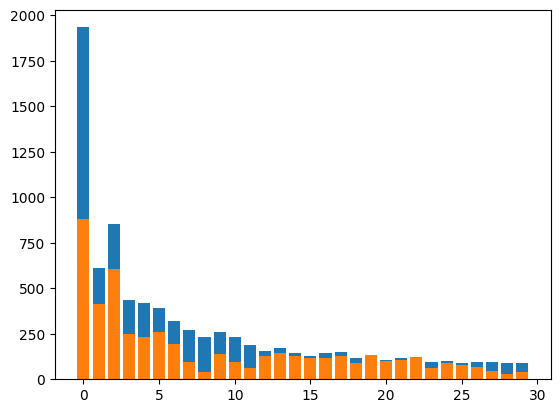

In [84]:
plt.bar(np.arange(30), np.var(mop_perturb_td, axis=0))
plt.bar(np.arange(30), np.var(np.array(mop_perturb_td @ comm_model.projector_mx), axis=0))

<BarContainer object of 30 artists>

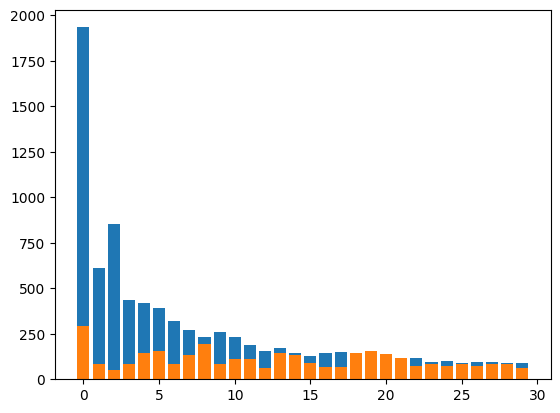

In [85]:
plt.bar(np.arange(30), np.var(mop_perturb_td, axis=0))
plt.bar(np.arange(30), np.var(mop_perturb_td - np.array(mop_perturb_td @ comm_model.projector_mx), axis=0))

In [86]:
mop_perturb_td = np.stack(perturb_td.MOp_rates_pca.values)
proj_mop_perturb_td = np.array([arr @ comm_model.projector_mx for arr in mop_perturb_td])
proj_mop_perturb_td.shape

(329, 201, 30)

In [59]:
def plot_comm_subspaces(ax, scores, pairs, errorStat = scipy.stats.sem, title='All components. 10 ms windows'):

    for from_area, to_area in pairs:
        line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores[from_area][to_area], errorStat=errorStat, label=f'{from_area}-> {to_area}')
    
        ax.axvline(x=times[np.argmax(scores[from_area][to_area].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

    ax.axvline(x=0, color='r', linestyle='dashed')
    ax.axhline(y=1/12, color='k', linestyle='dashed')
    ax.set_xlabel('Time rel. perturb. (s)')
    ax.set_ylabel('Accuracy')
    # ax.set_ylim(0, 0.5)
    ax.legend()
    # ax.set_xlim(0, 0.5)
    ax.set_title(f'{handler.session}. {title}')
    

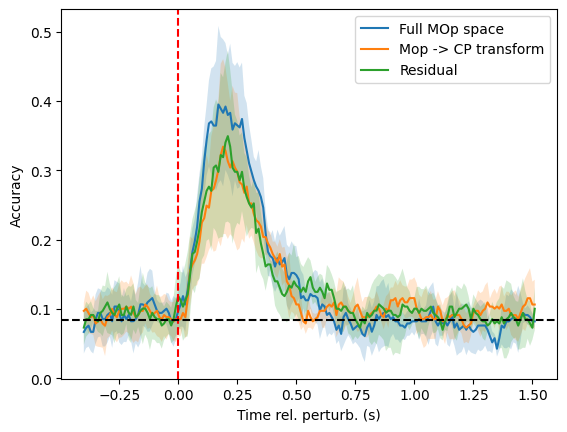

In [79]:
scores, times = decode.moving_window_decoding(
    proj_mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)

scores_, times = decode.moving_window_decoding(
    mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)

scores__, times = decode.moving_window_decoding(
    mop_perturb_td - proj_mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)



fig, ax = plt.subplots()
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores_, errorStat=np.std, label='Full MOp space')
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, errorStat=np.std, label='Mop -> CP transform')
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores__, errorStat=np.std, label='Residual')

    
# ax.axvline(x=times[np.argmax(scores[from_area][to_area].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
# ax.set_ylim(0, 0.5)
ax.legend()
# ax.set_xlim(0, 0.5)
# ax.set_title(f'{handler.session}. {title}')

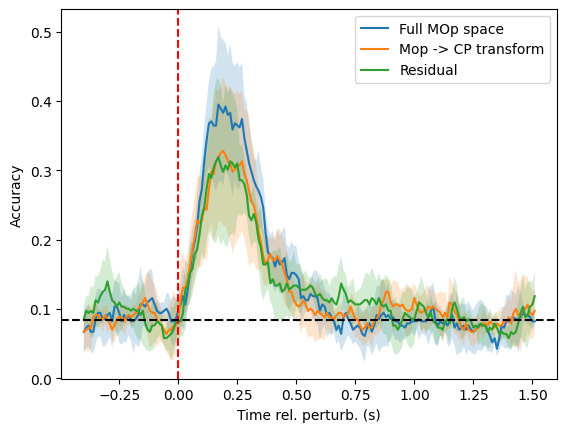

In [87]:
scores, times = decode.moving_window_decoding(
    proj_mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)

scores_, times = decode.moving_window_decoding(
    mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)

scores__, times = decode.moving_window_decoding(
    mop_perturb_td - proj_mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)



fig, ax = plt.subplots()
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores_, errorStat=np.std, label='Full MOp space')
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, errorStat=np.std, label='Mop -> CP transform')
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores__, errorStat=np.std, label='Residual')

    
# ax.axvline(x=times[np.argmax(scores[from_area][to_area].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
# ax.set_ylim(0, 0.5)
ax.legend()
# ax.set_xlim(0, 0.5)
# ax.set_title(f'{handler.session}. {title}')

(30, 30)


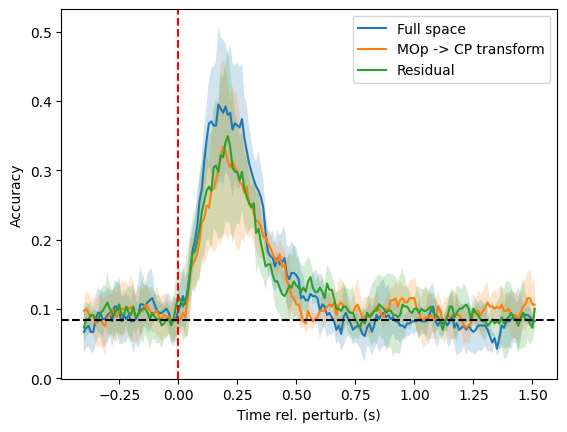

In [97]:
area1= 'MOp'
area2='CP'

mop = np.concatenate(df[f"{area1}_rates_pca"].values)
cp = np.concatenate(df[f"{area2}_rates_pca"].values)

mop_perturb_td = np.concatenate(perturb_td[f"{area1}_rates_pca"].values)

comm_model = subspaces.ReducedRankCommSubspace(rank=10, reg=0.05)
comm_model.fit(mop, cp)

mop_perturb_td = np.stack(perturb_td[f"{area1}_rates_pca"].values)
proj_mop_perturb_td = np.array([arr @ comm_model.projector_mx for arr in mop_perturb_td])


scores, times = decode.moving_window_decoding(
    proj_mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)

scores_, times = decode.moving_window_decoding(
    mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)

scores__, times = decode.moving_window_decoding(
    mop_perturb_td - proj_mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)



fig, ax = plt.subplots()
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores_, errorStat=np.std, label=f'Full space')
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, errorStat=np.std, label=f'{area1} -> {area2} transform')
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores__, errorStat=np.std, label=f'Residual')

    
# ax.axvline(x=times[np.argmax(scores[from_area][to_area].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
# ax.set_ylim(0, 0.5)
ax.legend()
# ax.set_xlim(0, 0.5)
# ax.set_title(f'{handler.session}. {title}')

(30, 30)


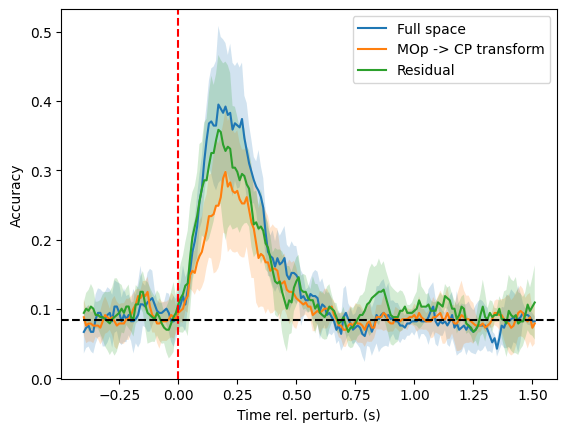

In [133]:
area1= 'MOp'
area2='CP'

mop = np.concatenate(df[f"{area1}_rates_pca"].values)
cp = np.concatenate(df[f"{area2}_rates_pca"].values)

mop_perturb_td = np.concatenate(perturb_td[f"{area1}_rates_pca"].values)

comm_model = subspaces.ReducedRankCommSubspace(rank=5, reg=0.05)
comm_model.fit(mop, cp)

mop_perturb_td = np.stack(perturb_td[f"{area1}_rates_pca"].values)
proj_mop_perturb_td = np.array([arr @ comm_model.projector_mx for arr in mop_perturb_td])


scores, times = decode.moving_window_decoding(
    proj_mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)

scores_, times = decode.moving_window_decoding(
    mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)

scores__, times = decode.moving_window_decoding(
    mop_perturb_td - proj_mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)



fig, ax = plt.subplots()
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores_, errorStat=np.std, label=f'Full space')
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, errorStat=np.std, label=f'{area1} -> {area2} transform')
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores__, errorStat=np.std, label=f'Residual')

    
# ax.axvline(x=times[np.argmax(scores[from_area][to_area].mean(axis=-1))]-0.5, color=line.get_color(), linestyle='dashed')

ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
# ax.set_ylim(0, 0.5)
ax.legend()
# ax.set_xlim(0, 0.5)
# ax.set_title(f'{handler.session}. {title}')

<BarContainer object of 30 artists>

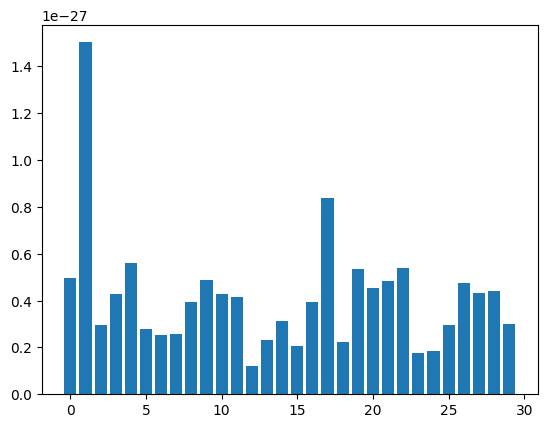

In [110]:
# plt.bar(np.arange(30), np.var(mop_perturb_td.reshape(-1, 30), axis=0))
plt.bar(np.arange(30), np.var((mop_perturb_td - proj_mop_perturb_td).reshape(-1, 30), axis=0))
# plt.bar(np.arange(30), np.var(proj_mop_perturb_td.reshape(-1, 30), axis=0))


(<matplotlib.lines.Line2D at 0x7ecaa030f350>,
 <matplotlib.collections.FillBetweenPolyCollection at 0x7ecab03b67b0>)

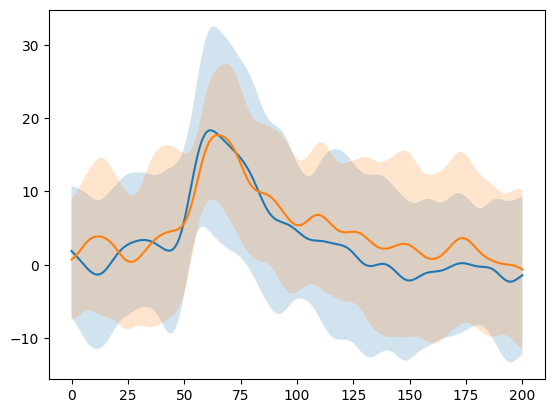

In [134]:
residual =  mop_perturb_td - proj_mop_perturb_td
# residual.shape
sol_0_idx = np.where(np.array(targets) == 0)[0]
sol_0_trials = residual[sol_0_idx, :, :]

sol_1_idx = np.where(np.array(targets) == 1)[0]
sol_1_trials = residual[sol_1_idx, :, :]


fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, sol_0_trials[:, :, 2].T)
vizutils.shaded_errorbar(ax, sol_1_trials[:, :, 2].T)

## Newer attempt

In [7]:
from sklearn.linear_model import Ridge

handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_05_14_00',
    combine_time_bins=False
)
df_ = handler.df

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
field idx_motion could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/

Resulting SSp_spikes ephys data shape is (NxT): (118, 60000)
Resulting all_spikes ephys data shape is (NxT): (24, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (219, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (100, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (155, 60000)
Resulting CP_spikes ephys data shape is (NxT): (195, 60000)


In [8]:
# Define trials and targets
df = dt.add_pca_df(df_, n_components=30)
df = pyal.select_trials(df, df.trial_name == 'trial')
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -50, rel_end= 150)
targets = df.values_Sol_direction.values.tolist()

In [9]:
# Define areas
mop = np.concatenate(df.MOp_rates_pca.values)
ssp = np.concatenate(df.SSp_rates_pca.values)
cp = np.concatenate(df.CP_rates_pca.values)
val = np.concatenate(df.VAL_rates_pca.values)


# Fit communication model
comm_model = Ridge(alpha=0.05).fit(mop, cp)

In [14]:
comm_model.coef_.shape

(28, 30)

In [31]:
# Mop data around perturbation
mop_perturb_td = np.stack(perturb_td.MOp_rates_pca.values)
mop_perturb_td_flat = np.concatenate(perturb_td.MOp_rates_pca.values)


# Project into the comm space
proj_mop_perturb_td = np.array([arr @ comm_model.coef_.T for arr in mop_perturb_td])


<BarContainer object of 30 artists>

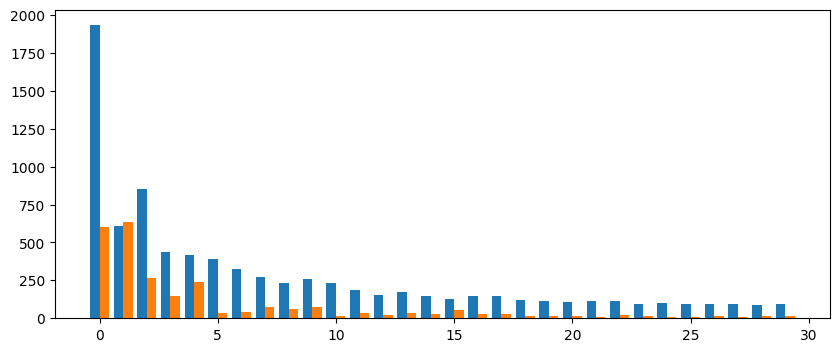

In [38]:

x = np.arange(30)
bar_width = 0.4
plt.figure(figsize=(10, 4))
# First set
plt.bar(x - bar_width/2, np.var(mop_perturb_td_flat, axis=0), 
        width=bar_width, label="mop_perturb")

# Second set
plt.bar(x + bar_width/2, np.var(proj_mop_perturb_td.reshape(-1, 30), axis=0), 
        width=bar_width, label="proj_mop_perturb")

In [39]:
# Decoding
scores_proj, times = decode.moving_window_decoding(
    proj_mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)
scores, times = decode.moving_window_decoding(
    mop_perturb_td,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=5
)

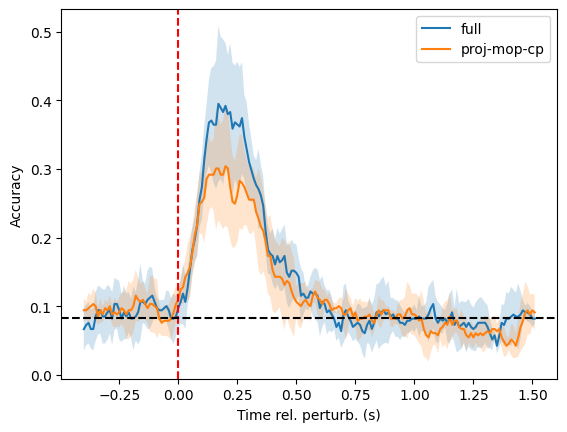

In [41]:
fig, ax = plt.subplots()
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, 
                                   errorStat=np.std, label='full')
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores_proj, 
                                   errorStat=np.std, label='proj-mop-cp')


ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
# ax.set_ylim(0, 0.5)
ax.legend()
# ax.set_xlim(0, 0.5)
# ax.set_title(f'{handler.session}. {title}')

### Refactored

In [49]:
def fit_ridge(X, y, alpha=0.05):
    return Ridge(alpha).fit(X, y)

def project_area(arr_, comm_model):
    return np.array([arr @ comm_model.coef_.T for arr in arr_])


def plot_expl_var(full_arr, proj_arr, title, n_comp=30):
    x = np.arange(n_comp)
    bar_width = 0.4
    plt.figure(figsize=(10, 4))
    # First set
    plt.bar(x - bar_width/2, np.var(full_arr.reshape(-1, n_comp), axis=0), 
            width=bar_width, label="full")

    # Second set
    plt.bar(x + bar_width/2, np.var(proj_arr.reshape(-1, n_comp), axis=0), 
            width=bar_width, label="proj")
    plt.legend()
    plt.title(title)

def decode_sol_pos(full_arr_td, comm_model, title):
    proj_arr_td = project_area(full_arr_td, comm_model)

    # Decoding
    scores_proj, times = decode.moving_window_decoding(
        proj_arr_td,
        targets,
        window_length_bin=10,
        step_bin=1,
        k=5
    )
    scores, times = decode.moving_window_decoding(
        full_arr_td,
        targets,
        window_length_bin=10,
        step_bin=1,
        k=5
    )

    fig, ax = plt.subplots()
    line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, 
                                    errorStat=np.std, label='full')
    line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores_proj, 
                                    errorStat=np.std, label='proj')


    ax.axvline(x=0, color='r', linestyle='dashed')
    ax.axhline(y=1/12, color='k', linestyle='dashed')
    ax.set_xlabel('Time rel. perturb. (s)')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.set_ylim([0, 0.55])
    ax.set_title(title)
    
    
def check_expl_var_projection_and_decode_sol_pos(area1_arr, area2_arr, area1_perturb_td, title='Full vs. projection'):
    comm_model = fit_ridge(area1_arr, area2_arr)
    proj_arr = project_area(area1_arr, comm_model)
    plot_expl_var(area1_arr, proj_arr, title=title)
    decode_sol_pos(area1_perturb_td, comm_model, title)

    

In [34]:
mop_perturb_td = np.stack(perturb_td.MOp_rates_pca.values)

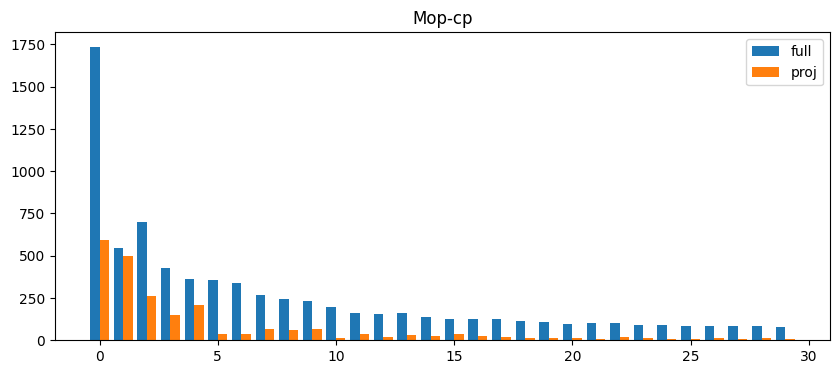

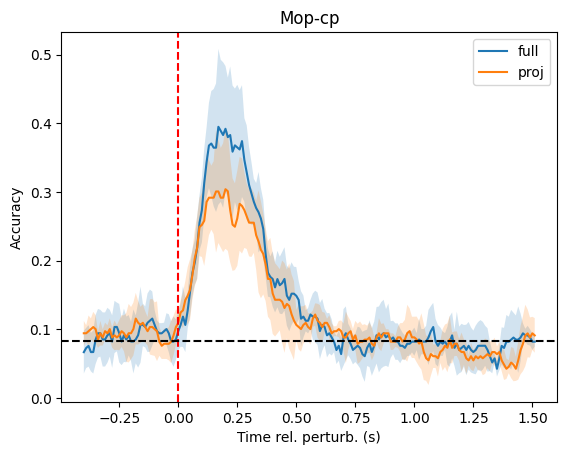

In [41]:
check_expl_var_projection_and_decode_sol_pos(mop, cp, mop_perturb_td, title='Mop-cp')


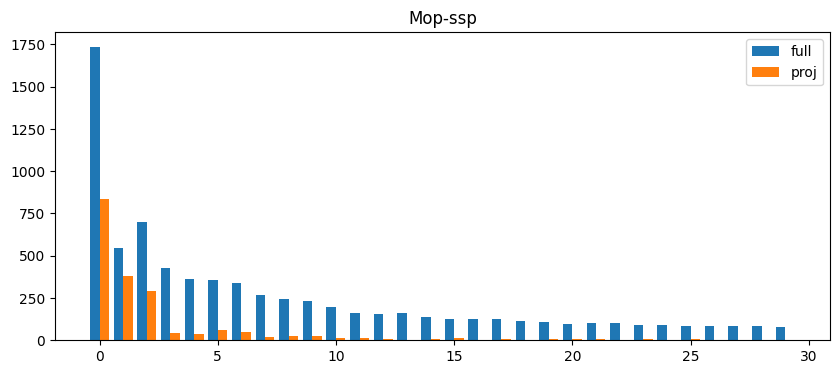

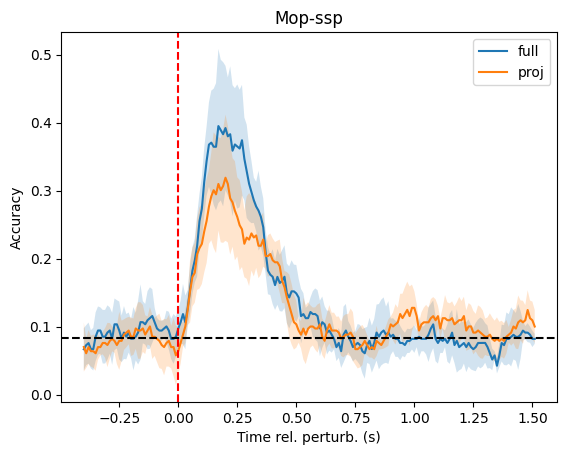

In [42]:
check_expl_var_projection_and_decode_sol_pos(mop, ssp, mop_perturb_td, title='Mop-ssp')


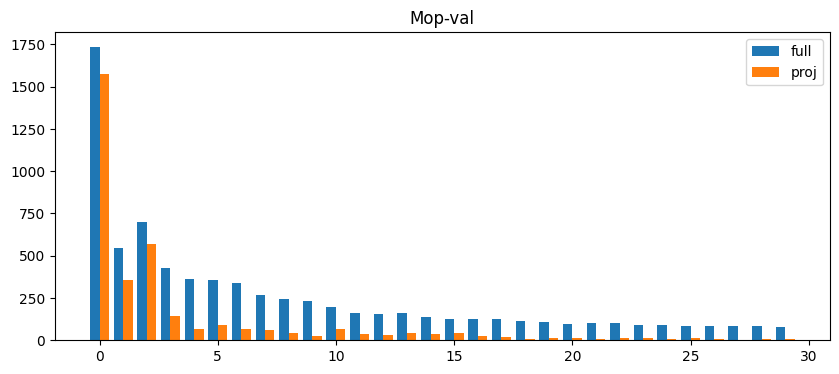

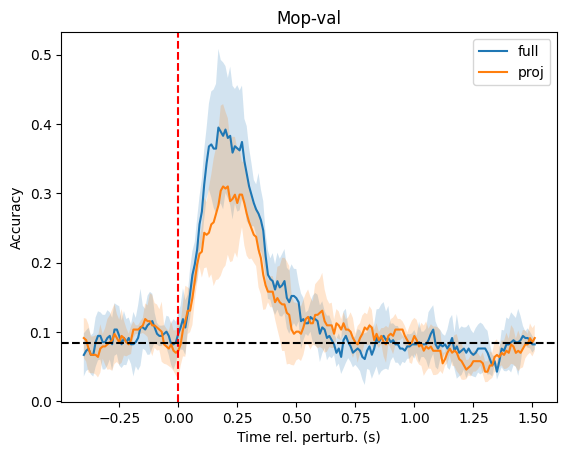

In [43]:
check_expl_var_projection_and_decode_sol_pos(mop, val, mop_perturb_td, title='Mop-val')


In [44]:
cp_perturb_td = np.stack(perturb_td.CP_rates_pca.values)


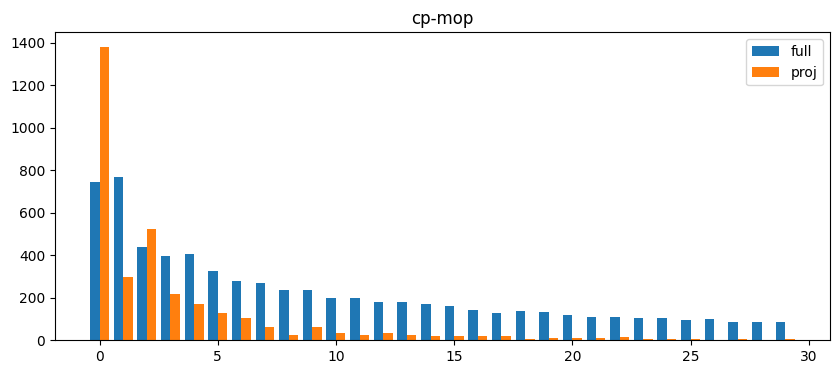

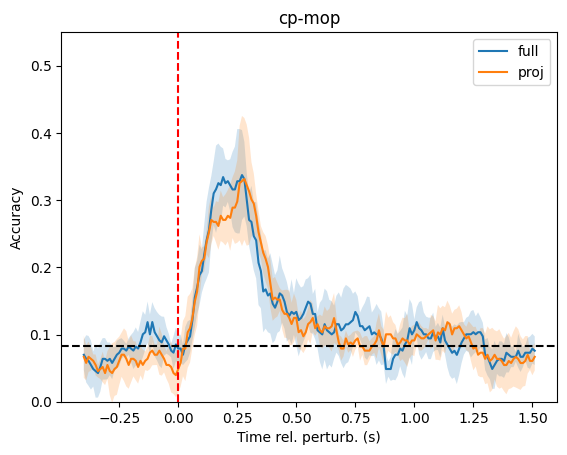

In [50]:
check_expl_var_projection_and_decode_sol_pos(cp, mop, cp_perturb_td, title='cp-mop')


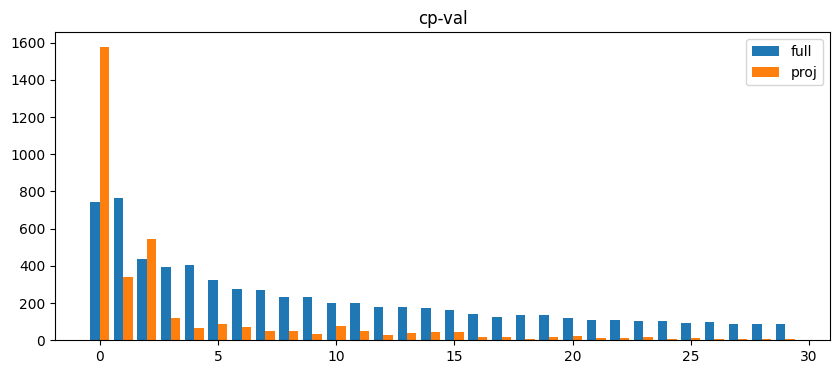

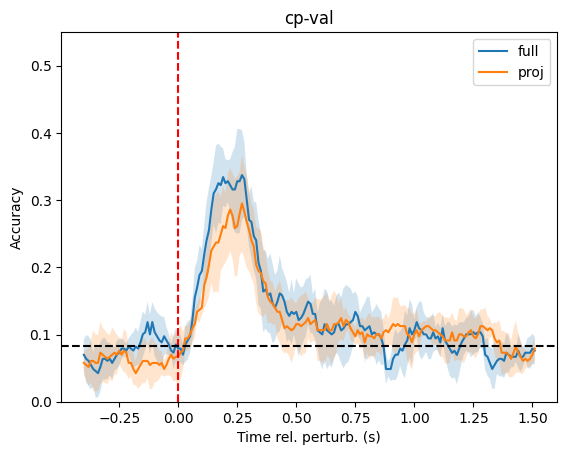

In [51]:
check_expl_var_projection_and_decode_sol_pos(cp, val, cp_perturb_td, title='cp-val')


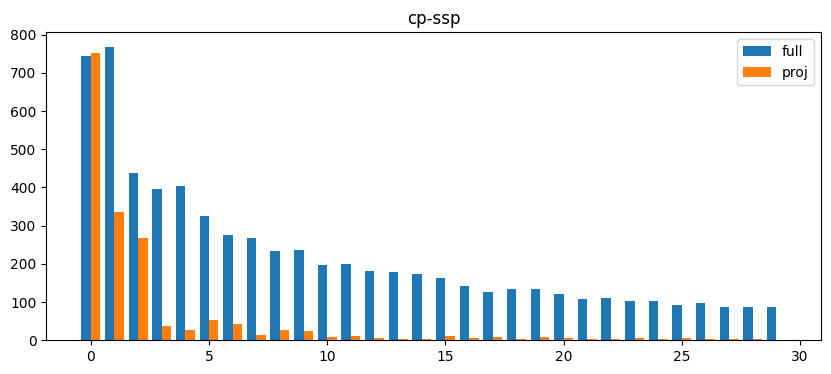

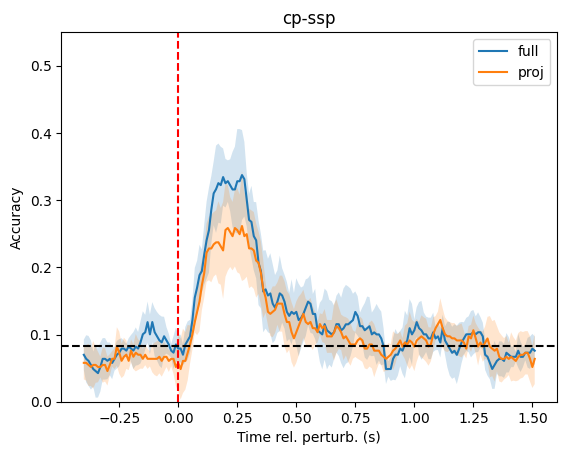

In [52]:
check_expl_var_projection_and_decode_sol_pos(cp, ssp, cp_perturb_td, title='cp-ssp')


In [53]:
val_perturb_td = np.stack(perturb_td.VAL_rates_pca.values)

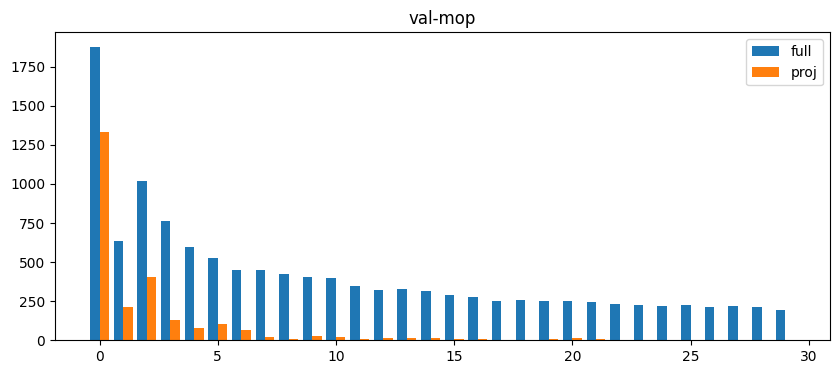

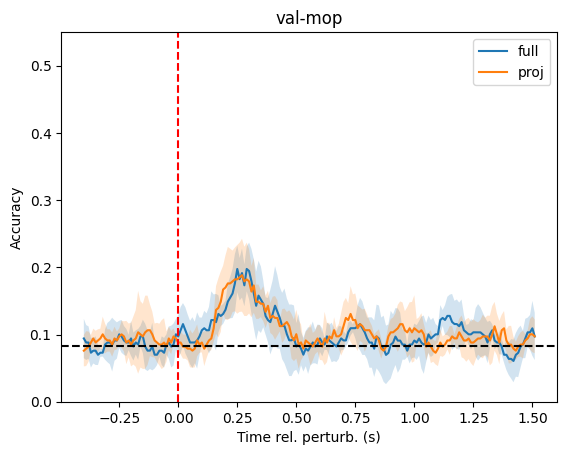

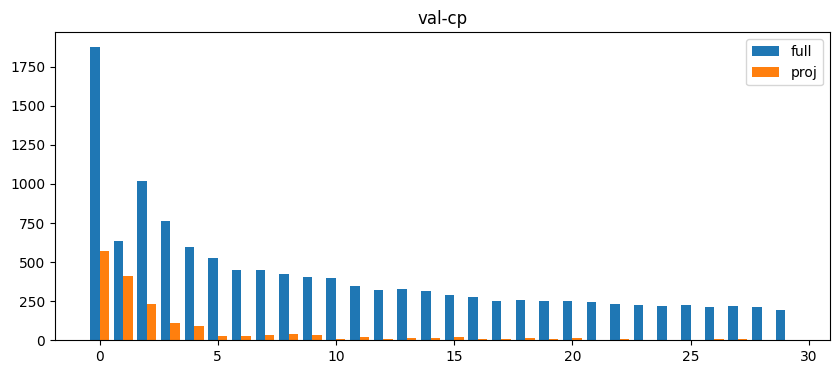

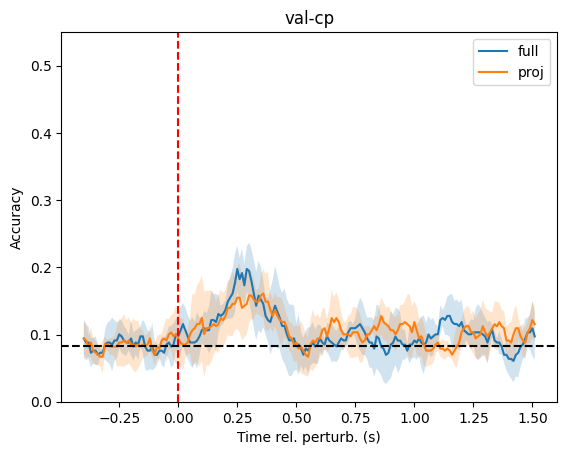

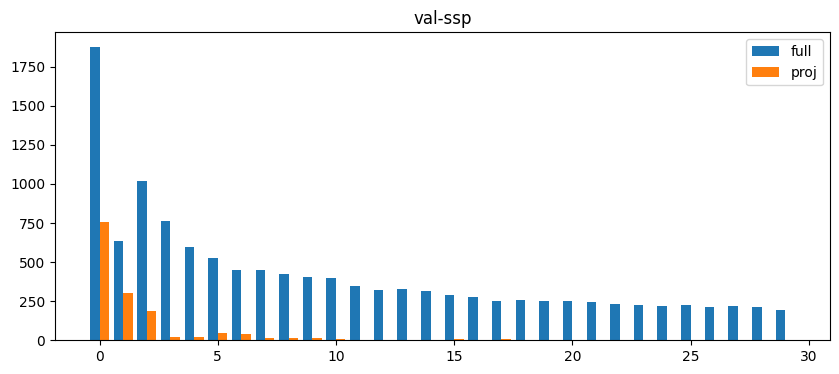

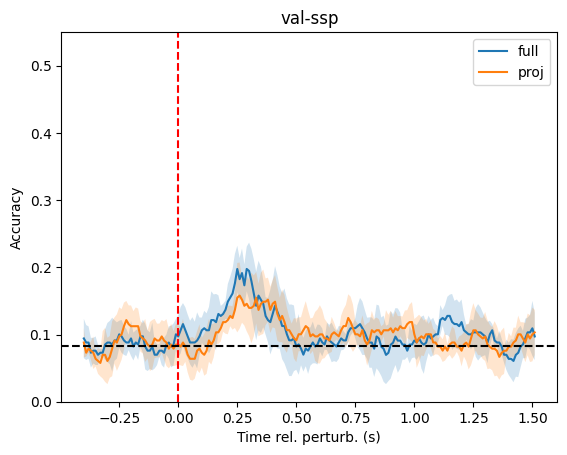

In [54]:
check_expl_var_projection_and_decode_sol_pos(val, mop, val_perturb_td, title='val-mop')
check_expl_var_projection_and_decode_sol_pos(val, cp, val_perturb_td, title='val-cp')
check_expl_var_projection_and_decode_sol_pos(val, ssp, val_perturb_td, title='val-ssp')
